‎ 

> # 1. Quantum Teleportation


For the quantum teleportation we will be implementing the following quantum circuit :

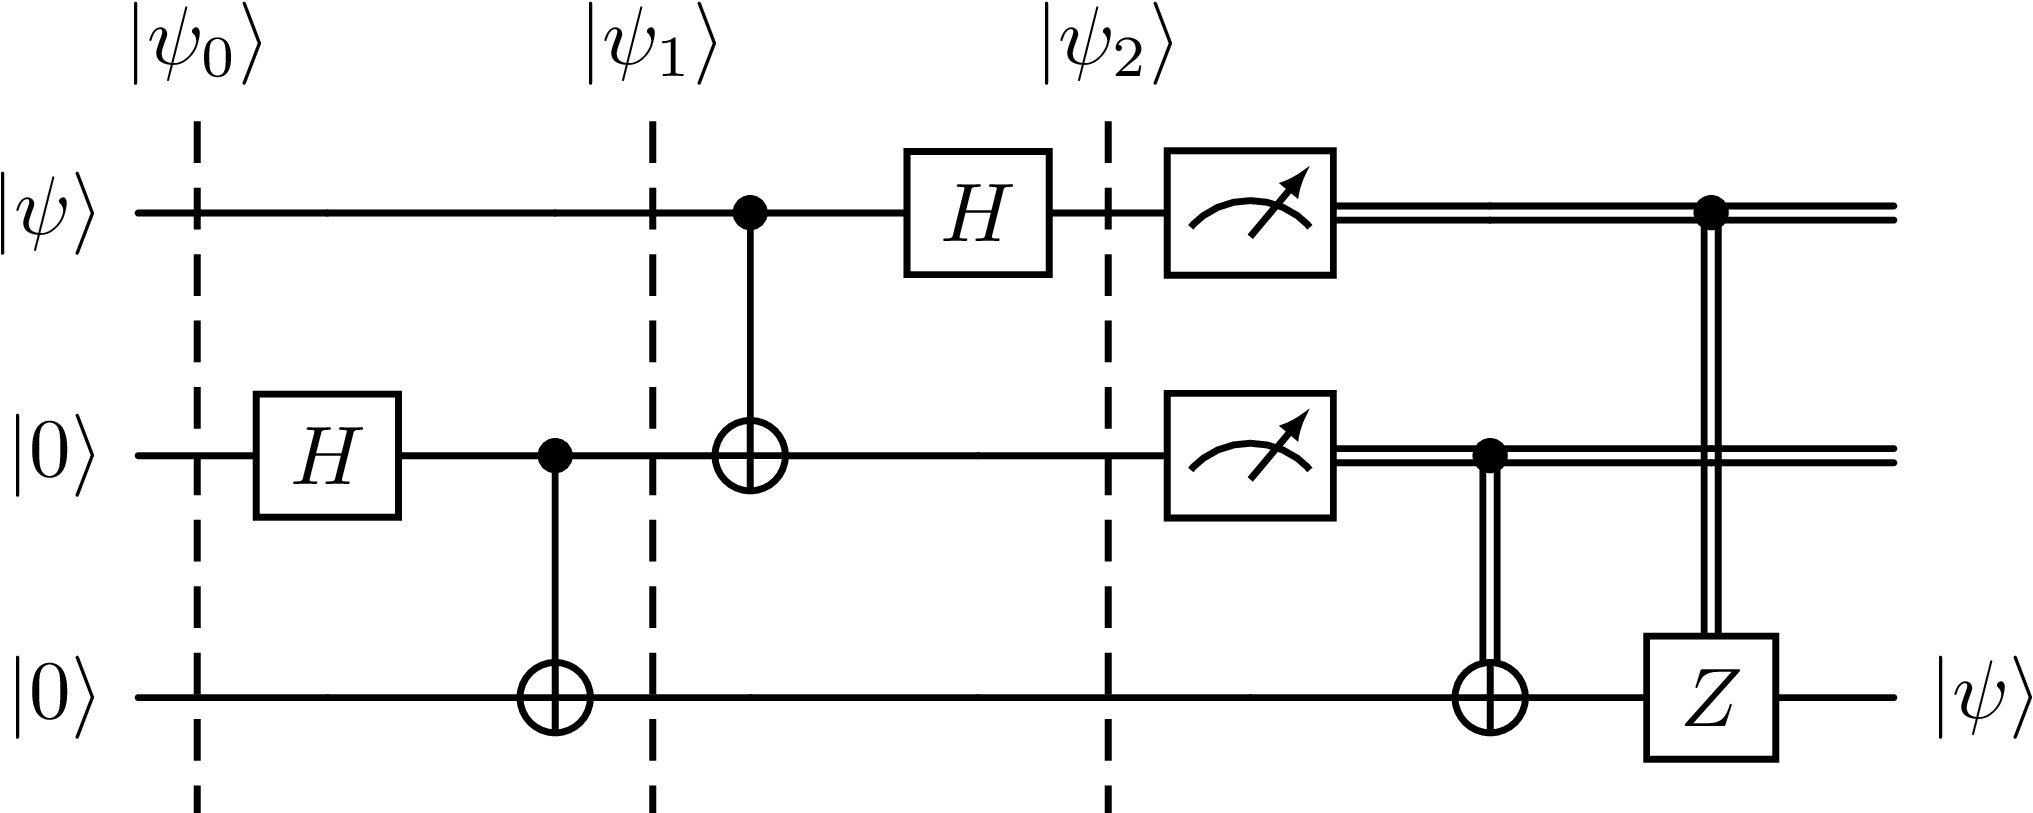

‎ 

___

‎ 

$$
\begin{align*}
\ket{\psi_1} &= \ket{\psi} \otimes \ket{\beta_{00}}
= (\alpha \ket{0} + \beta \ket{1}) \tfrac{1}{\sqrt{2}}(\ket{00} + \ket{11}) = \tfrac{1}{\sqrt{2}} \big( \alpha \ket{000} + \alpha \ket{011} + \beta \ket{100} + \beta \ket{111} \big)\\[16pt]
\ket{\psi_{2}} &= CNOT_{1,2} \ket{\psi_1} = \tfrac{1}{\sqrt{2}} \big( \alpha \ket{000} + \alpha \ket{011} + \beta \ket{110} + \beta \ket{101} \big)\\[16pt]
\ket{\psi_{3}} &= H_1 \ket{\psi_{2}} \\
&= \tfrac{1}{\sqrt{2}} \Big[ \tfrac{1}{\sqrt{2}} (\ket{0}+\ket{1})\alpha \ket{00} 
+ \tfrac{1}{\sqrt{2}} (\ket{0}+\ket{1})\alpha \ket{11} 
+ \tfrac{1}{\sqrt{2}} (\ket{0}-\ket{1})\beta \ket{10} 
+ \tfrac{1}{\sqrt{2}} (\ket{0}-\ket{1})\beta \ket{01} \Big] \\
&= \tfrac{1}{2} \Big( \alpha (\ket{000} + \ket{100} + \ket{011} + \ket{111}) 
+ \beta (\ket{010} - \ket{110} + \ket{001} - \ket{101}) \Big) \\[6pt]
%
&= \tfrac{1}{2} \Big( \ket{00}(\alpha\ket{0}+\beta\ket{1}) 
+ \ket{01}(\alpha\ket{1}+\beta\ket{0}) 
+ \ket{10}(\alpha\ket{0}-\beta\ket{1}) 
+ \ket{11}(\alpha\ket{1}-\beta\ket{0}) \Big) \\[6pt]
%
&= \tfrac{1}{2} \Big( \ket{00}(I\ket{\psi}) 
+ \ket{01}(X\ket{\psi}) 
+ \ket{10}(Z\ket{\psi}) 
+ \ket{11}(XZ\ket{\psi}) \Big)
\end{align*}
$$



‎ 

<div style="background-color: #768b74; padding: 10px; width: 100%; border-radius: 5px;">

First, we need a way to make random states for the $|\psi \rangle$ state. For that, we will be using the `random_statevector` from `quantum info` qiskit module.

</div>

‎ 

In [89]:
from Requirements import *

In [90]:
random_psi = random_statevector(2)

print(random_psi)

Statevector([-0.70779883-0.57399124j,  0.29357815+0.28873298j],
            dims=(2,))


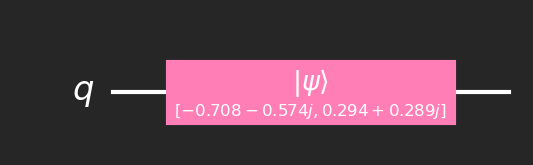

In [91]:
qc = QuantumCircuit(1)

qc.initialize(random_psi, 0)

qc.draw()

In [92]:
state = Statevector(qc)
alpha, beta = state.data

print(f"|ψ⟩ = ({np.round(alpha, 4)})|0⟩ + ({np.round(beta, 4)})|1⟩")

|ψ⟩ = ((-0.7078-0.574j))|0⟩ + ((0.2936+0.2887j))|1⟩



‎ 

<div style="background-color: #768b74; padding: 10px; width: 100%; border-radius: 5px;">

Now we can initialize the qc defining the registers accordingly, defining quantum registers and classical registers. After that we can populate the circuit with the corresponding algorithm gates. 

</div>

‎ 

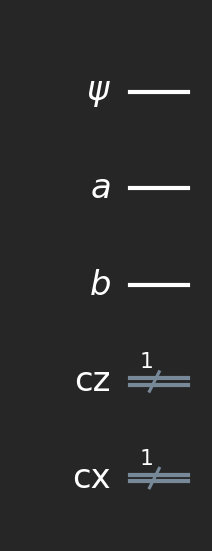

In [93]:
psi_qubit = QuantumRegister(1, name="ψ")
alice_qubit = QuantumRegister(1, name="a")
bob_qubit = QuantumRegister(1, name="b")

c_z = ClassicalRegister(1, name="cz") 
c_x = ClassicalRegister(1, name="cx")

qc = QuantumCircuit(psi_qubit, alice_qubit, bob_qubit, c_z, c_x)

qc.draw()

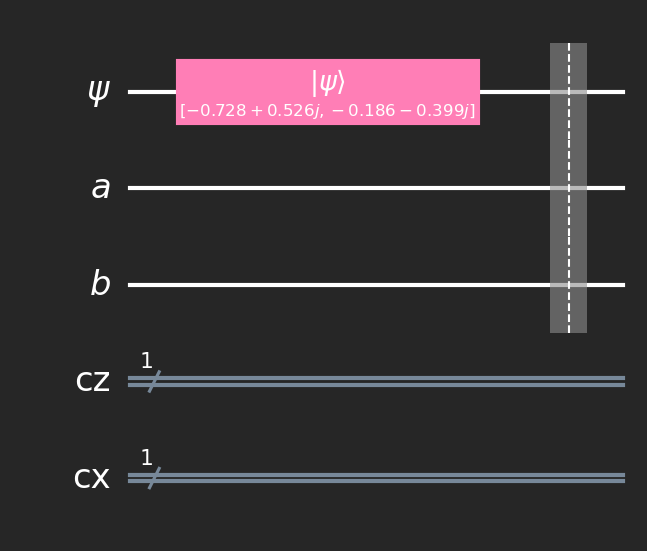

In [94]:
random_psi = random_statevector(2)

qc.initialize(random_psi, psi_qubit)

qc.barrier()

qc.draw()

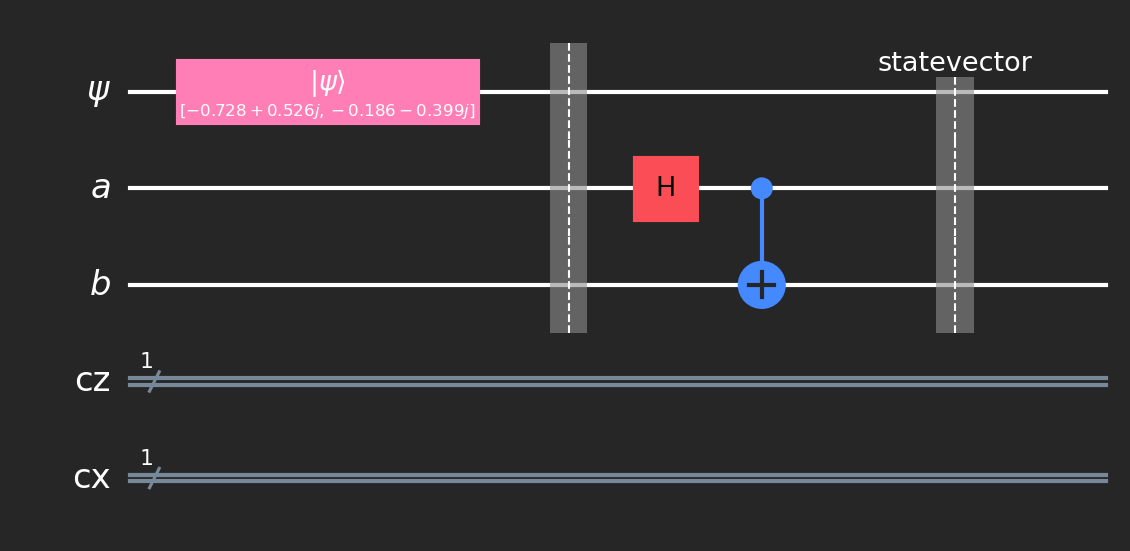

In [95]:
qc.h(alice_qubit)

qc.cx(alice_qubit, bob_qubit)

qc.save_statevector()

qc.draw()


In [96]:
simulator_aer = AerSimulator()

result = simulator_aer.run(qc).result()

ψ_1 = result.get_statevector()

display(ψ_1)

<IPython.core.display.Latex object>


‎ 

____

‎ 


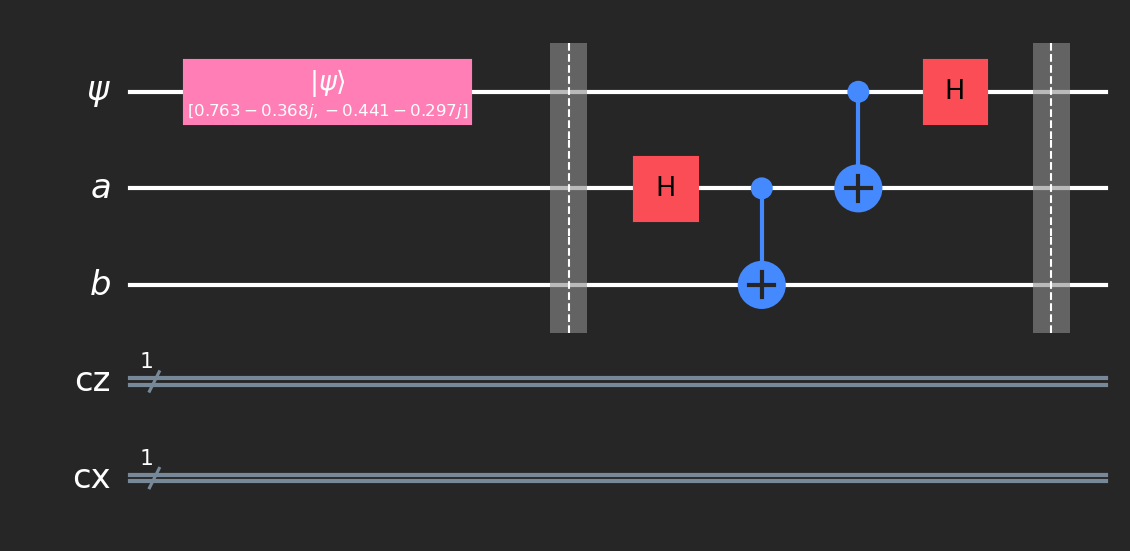

In [97]:
psi_qubit = QuantumRegister(1, name="ψ")
alice_qubit = QuantumRegister(1, name="a")
bob_qubit = QuantumRegister(1, name="b")

c_z = ClassicalRegister(1, name="cz") 
c_x = ClassicalRegister(1, name="cx")

qc = QuantumCircuit(psi_qubit, alice_qubit, bob_qubit, c_z, c_x)

random_psi = random_statevector(2)

qc.initialize(random_psi, psi_qubit)

qc.barrier()

qc.h(alice_qubit)

qc.cx(alice_qubit, bob_qubit)

qc.cx(psi_qubit, alice_qubit)

qc.h(psi_qubit)

qc.barrier()

qc.draw()

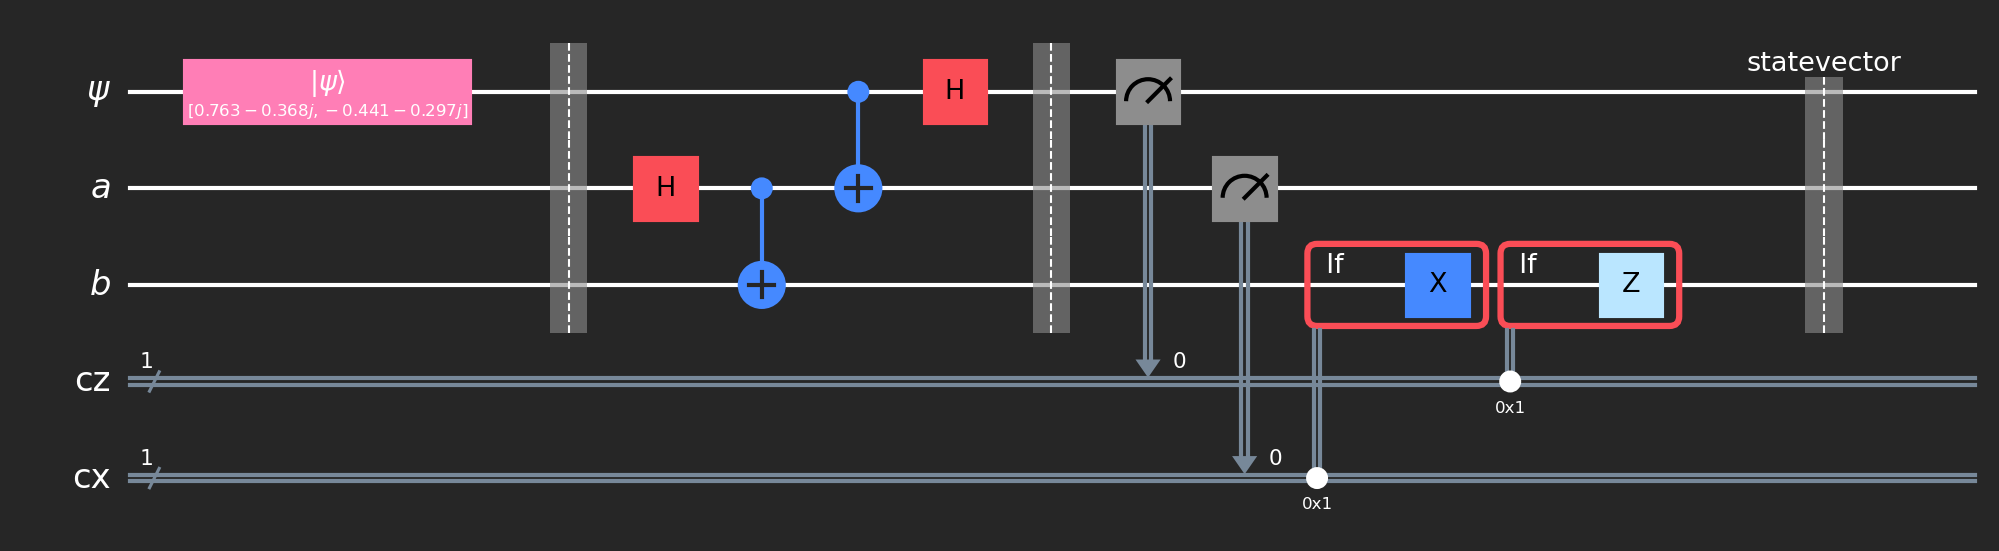

In [98]:
qc.measure(psi_qubit, c_z)
qc.measure(alice_qubit, c_x)

with qc.if_test((c_x, 1)):
    qc.x(bob_qubit)
    
with qc.if_test((c_z, 1)):
    qc.z(bob_qubit)
    
qc.save_statevector()
    
qc.draw()

In [115]:
simulator = AerSimulator()

result = simulator.run(qc, shots=1).result()

final_state_vector = result.get_statevector()

counts = result.get_counts()

alice_measurement_result = list(counts.keys())[0] 

display(final_state_vector)

<IPython.core.display.Latex object>

In [118]:
alice_result_int = int(alice_measurement_result.replace(" ", ""), 2)

alpha_final = final_state_vector.data[alice_result_int]
beta_final = final_state_vector.data[alice_result_int + 4]
bob_final_state = np.array([alpha_final, beta_final])

print(f"Bob:\n{np.round(bob_final_state, 4)}\n")
print(f"Original |ψ⟩:\n{np.round(random_psi.data, 4)}\n")

Bob:
[ 0.7628-0.3682j -0.4407-0.2974j]

Original |ψ⟩:
[ 0.7628-0.3682j -0.4407-0.2974j]

